Task 1: Load the diabetes dataset and display the first 20 rows. Identify the target variable and list all feature names.

In [121]:

import pandas as pd
df = pd.read_csv("extracted_data/diabetes.csv")
df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


Task 2: Generate descriptive statistics for all features including count, mean, std, min, 25%, 50%, 75%, and max values.



In [122]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Task 3: Create a count plot showing the distribution of the target variable (diabetic vs non-diabetic). Calculate the percentage of each class.

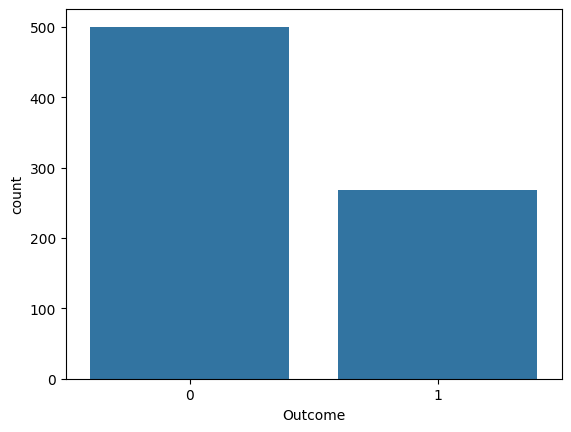

,proportion
Outcome,
0,65.104167
1,34.895833


In [110]:
sns.countplot(x="Outcome", data=df)
plt.show()

df["Outcome"].value_counts(normalize=True) * 100


Task 4: Identify features with zero values that should not logically be zero. Report how many such anomalous zeros exist in each feature.

In [111]:
zero_features = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in zero_features:
    print(col, (df[col] == 0).sum())


Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


Task 5: Create violin plots for 'Glucose' and 'BMI' features, separated by the target variable.

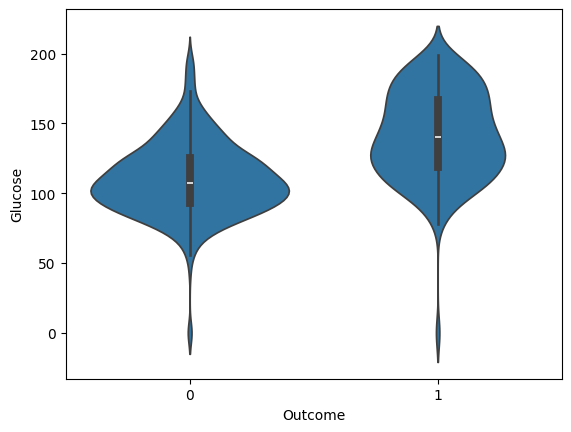

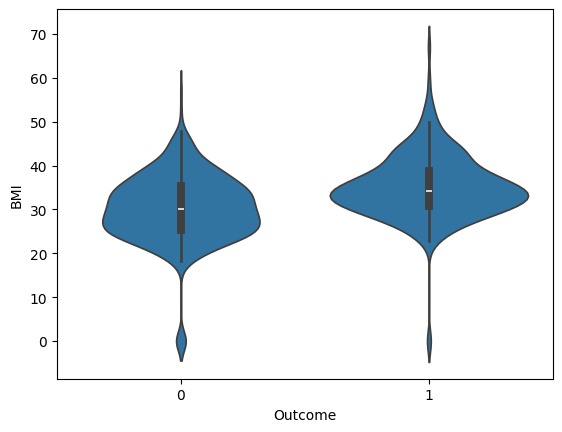

In [112]:
sns.violinplot(x="Outcome", y="Glucose", data=df)
plt.show()
sns.violinplot(x="Outcome", y="BMI", data=df)
plt.show()


Task 6: Replace zero values in features like 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', and 'BMI' with appropriate imputation strategies.

In [135]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("extracted_data/diabetes.csv")

# Features where zeros are invalid
zero_features = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

# Convert columns that will receive float means to float dtype to avoid FutureWarning
df["BloodPressure"] = df["BloodPressure"].astype(float)
df["BMI"] = df["BMI"].astype(float)

# Median imputation for skewed features
for col in ["Glucose","SkinThickness","Insulin"]:
    median_val = df.loc[df[col] != 0, col].median()
    df.loc[df[col] == 0, col] = median_val

# Mean imputation for normally distributed features
for col in ["BloodPressure","BMI"]:
    mean_val = df.loc[df[col] != 0, col].mean()
    df.loc[df[col] == 0, col] = mean_val

# Check if zeros are replaced
for col in zero_features:
    print(col, (df[col] == 0).sum())

Glucose 0
BloodPressure 0
SkinThickness 0
Insulin 0
BMI 0


Task 7: Create a new feature 'BMI_Category' by binning BMI values into categories. Visualize the relationship between BMI categories and diabetes outcome.

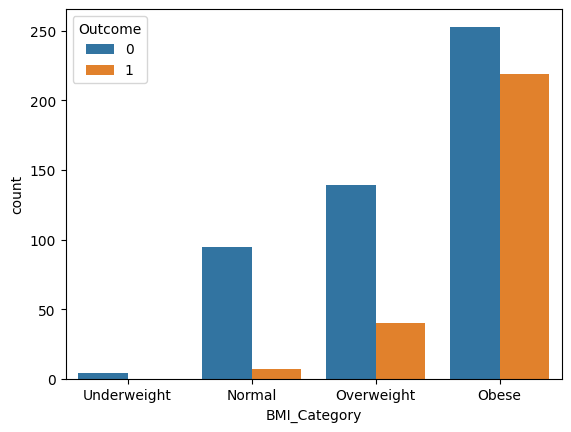

In [114]:
bins = [0,18.5,24.9,29.9,100]
labels = ["Underweight","Normal","Overweight","Obese"]
df["BMI_Category"] = pd.cut(df["BMI"], bins=bins, labels=labels)

sns.countplot(x="BMI_Category", hue="Outcome", data=df)
plt.show()


Task 8: Apply normalization using L2 norm to all features. Compare the magnitude of feature vectors before and after normalization.

In [116]:
normalizer = Normalizer(norm="l2")
X = df.drop(["Outcome", "BMI_Category"], axis=1)
X_norm = normalizer.fit_transform(X)

print("Before norm magnitude:", np.linalg.norm(X.iloc[0]))
print("After norm magnitude:", np.linalg.norm(X_norm[0]))

Before norm magnitude: 178.82492312035254
After norm magnitude: 1.0


Task 9: Implement a complete preprocessing pipeline that includes: (1) handling zero values with median imputation, (2) detecting and handling outliers using Z-score method, (3) applying StandardScaler, and (4) feature selection using Variance Threshold. Document each step with before/after comparisons.

In [130]:
# Step 1: Outlier removal using Z-score
from scipy.stats import zscore

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

z_scores = np.abs(zscore(X))
mask = (z_scores < 3).all(axis=1)
X_no_outliers = X[mask]
y_no_outliers = y[mask]

print("Original shape:", X.shape)
print("After outlier removal:", X_no_outliers.shape)

# Step 2: Standardization (manual)
X_standardized = (X_no_outliers - X_no_outliers.mean()) / X_no_outliers.std()

# Step 3: Variance Threshold (manual)
variances = X_standardized.var()
selected_features = variances[variances > 0.01].index
X_final = X_standardized[selected_features]

print("After variance threshold:", X_final.shape)
print("Selected features:", list(selected_features))


Original shape: (768, 8)
After outlier removal: (718, 8)
After variance threshold: (718, 8)
Selected features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


Task 10: Create three new engineered features and use SelectKBest with f_classif to evaluate their informativeness.

In [120]:
df["Glucose_to_Insulin_ratio"] = df["Glucose"] / (df["Insulin"] + 1)
df["Age_BMI_interaction"] = df["Age"] * df["BMI"]
df["Risk_Score"] = 0.5*df["Glucose"] + 0.3*df["BMI"] + 0.2*df["Age"]

X = df.drop(["Outcome", "BMI_Category"], axis=1)
y = df["Outcome"]

selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X, y)

scores = pd.DataFrame({"Feature": X.columns, "Score": selector.scores_})
scores.sort_values("Score", ascending=False)

,Feature,Score
10,Risk_Score,255.285938
1,Glucose,213.161752
9,Age_BMI_interaction,112.408722
5,BMI,71.772072
7,Age,46.140611
0,Pregnancies,39.670227
6,DiabetesPedigreeFunction,23.871300
8,Glucose_to_Insulin_ratio,16.549098
4,Insulin,13.281108
3,SkinThickness,4.304381
